#### Setup

In [1]:
import os

import numpy as np
import scipy
import pandas as pd

import matplotlib as mpl
import matplotlib.pyplot as plt

from tqdm import tqdm

import torch
import torch.nn as nn
import torchvision

import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader

from scipy.stats import binom

torch.set_printoptions(sci_mode=False)

In [2]:
%cd /home/atimans/Desktop/project_erc/erc

/home/atimans/Desktop/project_erc/erc


Experimental setup:

Introduce a probabilistic classifier and define an OOD detection problem. For every sample, the classifier's probabilities are leveraged to compute an outlier score, e.g., top-softmax probability. Introduce a threshold for binary outlier labelling: any outlier score above the threshold receives outlier label, any score below receives inlier label. Leverage risk control and calibration data to tune this threshold according to risk definition and tolerance level. Deploy model at test time online and track risk violation potential using e-process.

Experimental design:

- Pretrained probabilistic classifier
- Inlier data CIFAR-10, outlier data SVHN
- Risk definition: False Positive Rate (monotonic & in [0,1])
- Risk control: LTT

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

#### Using torchvision ImageNet-pretrained model (requires finetuning)

These models are only pretrained on ImageNet and require finetuning to perform optimally on e.g. CIFAR-10 or CIFAR-100. So would need a short training procedure.

In [4]:
# # Define preprocessing for CIFAR-10 and SVHN
# transform = transforms.Compose([
#     transforms.Resize(32),  # Resize to 32x32 for CIFAR and SVHN
#     transforms.ToTensor(),
#     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # Normalize for pretrained models
# ])

In [5]:
# cifar10_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
# cifar10_loader = DataLoader(cifar10_dataset, batch_size=64, shuffle=False)

# cifar100_dataset = datasets.CIFAR100(root='./data', train=False, download=True, transform=transform)
# cifar100_loader = DataLoader(cifar100_dataset, batch_size=64, shuffle=False)

# svhn_dataset = datasets.SVHN(root='./data', split='test', download=True, transform=transform)
# svhn_loader = DataLoader(svhn_dataset, batch_size=64, shuffle=False)

In [6]:
# print("Initial dataset shapes:")
# print(f"CIFAR-10: {cifar10_dataset.data.shape}")
# print(f"CIFAR-100: {cifar100_dataset.data.shape}")
# print(f"SVHN: {svhn_dataset.data.shape}")

# print("\nNr of classes and type:")
# print(f"CIFAR-10: {len(cifar10_dataset.classes), cifar10_dataset.classes}")
# print(f"CIFAR-100: {len(cifar100_dataset.classes), cifar100_dataset.classes}")
# print(f"SVHN: {len(np.unique(svhn_dataset.labels)), np.unique(svhn_dataset.labels)}")

# # Fully different classes
# print("\nCIFAR-10 vs. CIFAR-100 overlap:", set(cifar10_dataset.classes).intersection(set(cifar100_dataset.classes)))

In [7]:
# from torchvision.models import resnext50_32x4d, ResNeXt50_32X4D_Weights

# weights = ResNeXt50_32X4D_Weights.DEFAULT
# model = resnext50_32x4d(weights=weights)
# model.fc = nn.Linear(2048, 10)  # Modify for 10 classes (CIFAR-10 and SVHN)
# model.to("cpu")
# model.eval()

# # inference transforms for model
# preprocess = weights.transforms()

In [8]:
# img = torch.Tensor(cifar10_dataset.data[10]).permute(2, 0, 1)
# print(img.shape)

# img = preprocess(img).unsqueeze(0)
# print(img.shape)

# model(img).squeeze(0).softmax(0).detach().argmax(), cifar10_dataset.targets[10]

#### Using custom CIFAR-10 pretrained model

These models are taken from [this github](https://github.com/huyvnphan/PyTorch_CIFAR10) and already trained on CIFAR-10, so they are useable off the shelf.

In [9]:
from PyTorch_CIFAR10.cifar10_models.resnet import resnet50

In [10]:
model = resnet50(pretrained=True)
model.to(device)
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [11]:
# custom inference transforms for model (see github)
mean = [0.4914, 0.4822, 0.4465]
std = [0.2471, 0.2435, 0.2616]

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

# load datasets, and dataloaders with transforms
cifar10_dataset = datasets.CIFAR10(root='./data', train=False, transform=transform)
cifar10_loader = DataLoader(cifar10_dataset, batch_size=64, shuffle=False)

svhn_dataset = datasets.SVHN(root='./data', split='test', transform=transform)
svhn_loader = DataLoader(svhn_dataset, batch_size=64, shuffle=False)

In [12]:
print("Final dataset shape:")
print(f"CIFAR-10: {len(cifar10_loader.dataset), cifar10_loader.dataset.__getitem__(0)[0].shape}")
print(f"SVHN: {len(svhn_loader.dataset), svhn_loader.dataset.__getitem__(0)[0].shape}")

print("\nNr of classes and type:")
print(f"CIFAR-10: {len(cifar10_dataset.classes), cifar10_dataset.classes}")
print(f"SVHN: {len(np.unique(svhn_dataset.labels)), np.unique(svhn_dataset.labels)}")

Final dataset shape:
CIFAR-10: (10000, torch.Size([3, 32, 32]))
SVHN: (26032, torch.Size([3, 32, 32]))

Nr of classes and type:
CIFAR-10: (10, ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck'])
SVHN: (10, array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]))


In [13]:
# inference and collect predictions
def inference(loader, model):
    print(f"{len(loader.dataset) / loader.batch_size} batches of size {loader.batch_size}.")
    all_preds, all_conf = [], []
    
    with torch.no_grad():
        for images, _ in tqdm(loader, desc="Batch"):
            images = images.to(device)
            out = model(images).to('cpu')
            probs = nn.functional.softmax(out, dim=1)
            preds = torch.argmax(probs, dim=1)
            conf = outlier_score(probs)
            
            all_preds.extend(preds.numpy())
            all_conf.extend(conf.numpy())

    return (
        np.array(all_preds, dtype=np.int32), 
        np.array(all_conf, dtype=np.float32)
    )
    
def outlier_score(probs):
    # top softmax (low top confidence = outlier)
    # score = 1 - torch.max(probs, axis=1)[0]
    
    # normalized entropy (high entropy = outlier)
    score = - torch.sum(probs * torch.log(probs + 1e-10), axis=1) / torch.log(torch.tensor(probs.shape[1]).float())
    
    return score

In [14]:
# run inference on CIFAR-10 (inlier) and SVHN (outlier)
print("Running inference on CIFAR-10 (inlier) dataset...")
cifar10_preds, cifar10_conf = inference(cifar10_loader, model)

print("Running inference on SVHN (outlier) dataset...")
svhn_preds, svhn_conf = inference(svhn_loader, model)

Running inference on CIFAR-10 (inlier) dataset...
156.25 batches of size 64.


Batch: 100%|██████████| 157/157 [00:04<00:00, 31.89it/s]


Running inference on SVHN (outlier) dataset...
406.75 batches of size 64.


Batch: 100%|██████████| 407/407 [00:10<00:00, 37.93it/s]


In [15]:
cifar10_preds[:10], cifar10_conf[:10], svhn_preds[:10], svhn_conf[:10]

(array([3, 8, 8, 0, 6, 6, 1, 6, 3, 1], dtype=int32),
 array([0.04088298, 0.04695556, 0.0521585 , 0.04220984, 0.03846278,
        0.03930046, 0.04144964, 0.03868615, 0.03988957, 0.1317654 ],
       dtype=float32),
 array([3, 3, 3, 5, 3, 3, 5, 0, 3, 5], dtype=int32),
 array([0.40998998, 0.10691661, 0.62084115, 0.5790672 , 0.68884945,
        0.4737729 , 0.12189494, 0.36792052, 0.55023474, 0.04050966],
       dtype=float32))

In [16]:
# compute basic metrics
cifar10_accuracy = (cifar10_preds == cifar10_dataset.targets).mean()
svhn_accuracy = (svhn_preds == svhn_dataset.labels).mean()
print(f"CIFAR-10 accuracy: {cifar10_accuracy:.4f}")
print(f"SVHN accuracy: {svhn_accuracy:.4f}")

print(f"CIFAR-10 mean outlier score: {cifar10_conf.mean():.4f}")
print(f"SVHN mean outlier score: {svhn_conf.mean():.4f}")

CIFAR-10 accuracy: 0.9365
SVHN accuracy: 0.1036
CIFAR-10 mean outlier score: 0.0813
SVHN mean outlier score: 0.2791


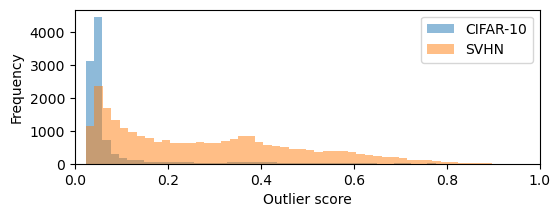

In [17]:
# plot histograms of outlier scores
plt.figure(figsize=(6, 2))
plt.hist(cifar10_conf, bins=50, alpha=0.5, label="CIFAR-10", density=False)
plt.hist(svhn_conf, bins=50, alpha=0.5, label="SVHN", density=False)
plt.xlabel("Outlier score")
plt.ylabel("Frequency")
plt.xlim(0, 1)
plt.legend()
plt.show()

#### Risk control via LTT

Learn-then-Test to determine an outlier threshold $\psi \in [0,1]$ with risk control.

In [18]:
def thresh_grid(min, max, step):
    """Create a grid of threshold values.

    Args:
        min (float): Minimum grid value.
        max (float): Maximum grid value.
        step (float): Step size between grid values.

    Returns:
        torch.Tensor: Grid of threshold values.
    """
    threshs = torch.arange(max, min, -step, dtype=torch.float)
    # every thresh has at most the same number of decimal points as step
    threshs = torch.round(threshs / step) * step
    return threshs


def hb_p_value(risk, n, eps, binary_loss: bool):
    """Compute the p-value of the Hoeffding-Bentkus bound. If binary loss, use the binomial CDF directly.
    Adapted from https://github.com/aangelopoulos/ltt/blob/main/core/bounds.py

    Args:
        risk: Computed risk estimate.
        n: Number of calibration samples.
        eps: Tolerated risk level.

    Returns:
        p-value.
    """
    if binary_loss:
        p_value = binom.cdf(np.ceil(n * risk), n, eps)
    else:
        bentkus_p_value = np.e * binom.cdf(np.ceil(n * risk), n, eps)
        a, b = min(risk, eps), eps
        h1 = a * np.log(a / b) + (1 - a) * np.log((1 - a) / (1 - b))
        hoeffding_p_value = np.exp(-n * h1)
        p_value = min(bentkus_p_value, hoeffding_p_value)

    assert 0 - 1e-4 <= p_value <= 1 + 1e-4, "p-value must be in [0, 1]: {}".format(p_value)
    return p_value


def get_ltt_thresh(losses, eps, delta, binary_loss=False, loss_B=1.0):
    # losses: (N_thresh, N_cal)
    # select thresh closest s.t. LTT p-value is controlled on calibration data
    
    # Note that LTT requires losses in [0, 1], thus we first need to rescale the losses if loss_B > 1
    losses = torch.max(torch.zeros_like(losses), (1 / loss_B) * losses)
    
    N_thresh, N_cal = losses.shape
    risk = losses.mean(dim=1) # (N_thresh,)
    
    pval = torch.zeros((N_thresh,))
    for i in range(N_thresh):
        pval[i] = torch.tensor([hb_p_value(risk[i].item(), N_cal, eps, binary_loss)])
    
    thresh_ids = (pval <= delta).nonzero(as_tuple=True)[0]
    if thresh_ids.shape[0] == 0: # no accept
        thresh_id = torch.tensor([0])
        thresh_ids = torch.tensor([0])
    else:
        thresh_id = thresh_ids[-1] # smallest thresh (from below)
    return thresh_id, thresh_ids, pval


In [471]:
# Define a grid of outlier threshold candidates in the range [0, 1]
thresh_cand = thresh_grid(0, 1, 0.01)
thresh_cand

tensor([1.0000, 0.9900, 0.9800, 0.9700, 0.9600, 0.9500, 0.9400, 0.9300, 0.9200,
        0.9100, 0.9000, 0.8900, 0.8800, 0.8700, 0.8600, 0.8500, 0.8400, 0.8300,
        0.8200, 0.8100, 0.8000, 0.7900, 0.7800, 0.7700, 0.7600, 0.7500, 0.7400,
        0.7300, 0.7200, 0.7100, 0.7000, 0.6900, 0.6800, 0.6700, 0.6600, 0.6500,
        0.6400, 0.6300, 0.6200, 0.6100, 0.6000, 0.5900, 0.5800, 0.5700, 0.5600,
        0.5500, 0.5400, 0.5300, 0.5200, 0.5100, 0.5000, 0.4900, 0.4800, 0.4700,
        0.4600, 0.4500, 0.4400, 0.4300, 0.4200, 0.4100, 0.4000, 0.3900, 0.3800,
        0.3700, 0.3600, 0.3500, 0.3400, 0.3300, 0.3200, 0.3100, 0.3000, 0.2900,
        0.2800, 0.2700, 0.2600, 0.2500, 0.2400, 0.2300, 0.2200, 0.2100, 0.2000,
        0.1900, 0.1800, 0.1700, 0.1600, 0.1500, 0.1400, 0.1300, 0.1200, 0.1100,
        0.1000, 0.0900, 0.0800, 0.0700, 0.0600, 0.0500, 0.0400, 0.0300, 0.0200,
        0.0100])

In [472]:
# Select a random subset of fixed size from the inlier data as calibration set
n_cal = int(0.3 * len(cifar10_preds))
cal_idx = torch.randperm(len(cifar10_preds))[:n_cal]
print(f"Using {n_cal} calibration samples.")
print(cal_idx[:10])

Using 3000 calibration samples.
tensor([ 322,  615, 3595, 3865,  533, 7777, 8757, 6396, 3993, 4891])


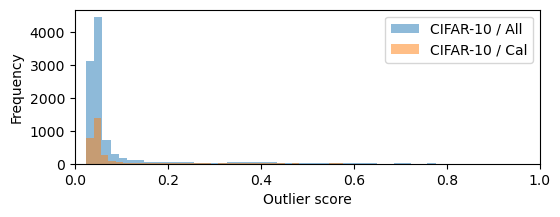

In [473]:
# assert that the calibration set is representative
plt.figure(figsize=(6, 2))
plt.hist(cifar10_conf, bins=50, alpha=0.5, label="CIFAR-10 / All", density=False)
plt.hist(cifar10_conf[cal_idx], bins=50, alpha=0.5, label="CIFAR-10 / Cal", density=False)
plt.xlabel("Outlier score")
plt.ylabel("Frequency")
plt.xlim(0, 1)
plt.legend()
plt.show()

Consider the risk as false positive rate. Then $FPR(\mathcal{D}_{cal}) = \frac{\#{FP}}{N_{cal}} \in [0,1]$, and a calibration sample $i$ is classified as $FP$ if its outlier score $out_i > \psi$ since all calibration samples are known to be in-distribution.

In [525]:
# collect losses in a grid of size (N_thresh, N_cal)

def get_loss(thresh, conf):
    return (conf > thresh)

def get_losses(thresh_cand, conf):
    n_thresh, n_cal = thresh_cand.shape[0], conf.shape[0]
    losses = torch.zeros((n_thresh, n_cal))
    
    for i, thresh in enumerate(thresh_cand):
        losses[i] = get_loss(thresh, conf).to(torch.float32)
    
    return losses

In [526]:
eps = 0.05 # risk level
delta = 0.1 # significance level

losses = get_losses(thresh_cand, torch.tensor(cifar10_conf[cal_idx]))
risk = losses.mean(dim=1)
thresh_id, thresh_ids, pval = get_ltt_thresh(losses, eps, delta, binary_loss=True)

print(f"Selected threshold: {thresh_cand[thresh_id]}, p-value: {pval[thresh_id]}, risk: {risk[thresh_id]}")

Selected threshold: 0.3799999952316284, p-value: 0.022328322753310204, risk: 0.0416666679084301


In [527]:
# visualize risk control decision
def plot_thresh_risk_pval(thresh, risk, pval, rc_psi, epsilon, delta, save_dir=None, save_name=None):
    """
    Plot the risk and p-value as a function of thresh.
    """

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 2.5))
    ax1.plot(thresh, risk, color="black")
    ax1.set_xlim(max(thresh) + 1e-2, 0 - 1e-3)
    ax1.set_xlabel(r"Threshold parameter $\psi$")
    ax1.set_ylabel("Risk")
    ax1.axhline(y=epsilon, color="red", ls=":", label=r"Risk level $\epsilon$", lw=2)
    ax1.axvline(
        x=rc_psi, color="green", ls=":", label=r"Risk controlling $\hat{\psi}$", lw=2
    )
    ax1.legend()

    ax2.plot(thresh, pval, color="black")
    ax2.set_xlim(max(thresh) + 1e-2, 0 - 1e-3)
    ax2.set_xlabel(r"Threshold parameter $\psi$")
    ax2.set_ylabel("P-value")
    ax2.axhline(y=epsilon, color="red", ls=":", label=r"Risk level $\epsilon$", lw=2)
    ax2.axvline(
        x=rc_psi, color="green", ls=":", label=r"Risk controlling $\hat{\psi}$", lw=2
    )
    ax2.legend()

    fig.suptitle(rf"Target guarantee: $\epsilon={epsilon}$, $\delta={delta}$")
    # fname = "thresh_risk_pval.png" if save_name is None else save_name
    # plt.savefig(
    #     os.path.join(save_dir, fname),
    #     bbox_inches="tight",
    # )
    plt.show()


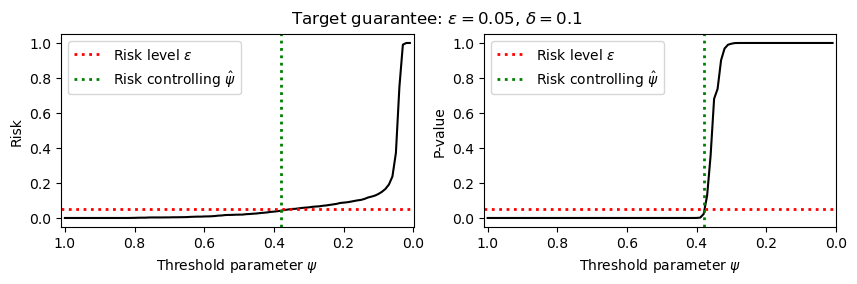

In [528]:
plot_thresh_risk_pval(thresh_cand, risk, pval, thresh_cand[thresh_id], eps, delta)

In [478]:
# Check the selected threshold on the test set
test_losses = get_losses(thresh_cand, torch.tensor(cifar10_conf[~cal_idx]))
test_risk = test_losses.mean(dim=1)

print(f"Test risk: {test_risk[thresh_id]}")

Test risk: 0.0416666679084301


In [479]:
def plot_test_risk(risk, losses, epsilon, delta, save_dir=None, save_name=None):
    """
    Plot the test risk and loss statistics.
    """
    fig, ax = plt.subplots(1, 1, figsize=(6, 2))
    ax.hist(
        losses,
        bins=30,
        density=True,
        color="lightgray",
        edgecolor="black",
        linewidth=1,
        alpha=0.8,
    )
    ax.set_ylabel("Density")
    ax.set_xlabel("Test losses")
    ax.set_xlim(-0.03, 1.03)
    ax.axvline(x=epsilon, color="red", ls="-", label=r"Risk level $\epsilon$", lw=2)
    ax.axvline(
        x=risk,
        color="green",
        ls="-",
        label=f"Test risk: {risk:.3f}",
        lw=2,
    )
    ax.legend()
    fig.suptitle("Risk control on test data")
    # fname = "test_risk.png" if save_name is None else save_name
    # plt.savefig(
    #     os.path.join(save_dir, fname),
    #     bbox_inches="tight",
    # )
    plt.show()

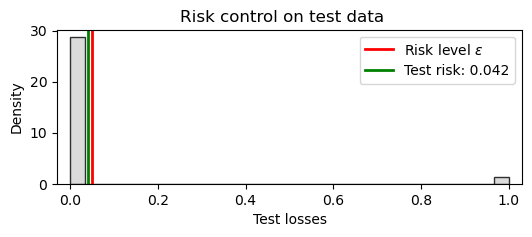

In [480]:
plot_test_risk(test_risk[thresh_id], test_losses[thresh_id], eps, delta)

#### Test stream setting

In [481]:
T = 10000 # nr of time steps
ood_prob = 0.15 # probability of OOD sample

cifar10_test_idx = ~torch.isin(torch.arange(len(cifar10_preds)), cal_idx)
cifar10_test_labels = torch.Tensor(cifar10_dataset.targets)[cifar10_test_idx]
cifar10_test_preds = torch.Tensor(cifar10_preds)[cifar10_test_idx]
cifar10_test_conf = torch.Tensor(cifar10_conf)[cifar10_test_idx]
cifar10_test_losses = get_losses(thresh_cand, cifar10_test_conf)

svhn_test_labels = torch.Tensor(svhn_dataset.labels)
svhn_test_preds = torch.Tensor(svhn_preds)
svhn_test_conf = torch.Tensor(svhn_conf)
svhn_test_losses = get_losses(thresh_cand, svhn_test_conf)

thresh = thresh_cand[thresh_id].unsqueeze(0)

print(f"Stream length: {T}")
print(f"OOD probability: {ood_prob}")
print(f"\nCIFAR-10 test losses: {cifar10_test_losses.shape}")
print(f"SVHN test losses: {svhn_test_losses.shape}")
print(f"Initial risk control threshold: {thresh.item():.4f}")

Stream length: 10000
OOD probability: 0.15

CIFAR-10 test losses: torch.Size([100, 7000])
SVHN test losses: torch.Size([100, 26032])
Initial risk control threshold: 0.3800


Note: FPR is not really an interesting risk to track in the case of label availability (after every time step), because it only concerns inlier data and does not incorporate outlier misclassification. I.e., the FP loss for any outlier sample will always be zero (outlier as inlier -> FN, outlier as outlier -> TN). 

Instead, consider tracking and controlling the total error rate $TPR = \frac{FP + FN}{\# data}$. In the case of only inlier data (as for calibration data), this is equal to the FPR. So, our risk control procedure on FPR is still valid.

In [482]:
stream_bern = torch.zeros(T)
stream_idx = torch.zeros(T)
stream_losses = torch.zeros(T)

# generate data stream
for t in tqdm(range(0, T), desc="Time step"):
    
    # simulate test sample (in or out of distribution)
    bern = np.random.binomial(1, ood_prob)
    
    if bern == 0: # in distribution
        i = np.random.randint(0, cifar10_test_losses.shape[1])
        loss = cifar10_test_losses[thresh_id, i] # FP: inlier as outlier
    else: # out of distribution
        i = np.random.randint(0, svhn_test_losses.shape[1])
        loss = 1.0 - svhn_test_losses[thresh_id, i] # FN: outlier as inlier
    
    stream_bern[t] = bern
    stream_idx[t] = i
    stream_losses[t] = loss

Time step: 100%|██████████| 10000/10000 [00:00<00:00, 30097.29it/s]


In [483]:
for t in range(50, 55):
    b = stream_bern[t]
    i = stream_idx[t].int()
    l = stream_losses[t]
    
    print(f"\nt = {t}, Bernoulli: {b}, Index: {i}")
    
    if b == 0:
        print(f"Inlier confidence: {cifar10_test_conf[i]:.4f} vs. threshold: {thresh.item():.4f} -> Loss = {l}")
        print(f"Predicted: {cifar10_test_preds[i]}, True: {cifar10_test_labels[i]}")
    else:
        print(f"Outlier confidence: {svhn_test_conf[i]:.4f} vs. threshold: {thresh.item():.4f} -> Loss = {l}")
        print(f"Predicted: {svhn_test_preds[i]}, True: {svhn_test_labels[i]}")


t = 50, Bernoulli: 0.0, Index: 309
Inlier confidence: 0.0616 vs. threshold: 0.3800 -> Loss = 0.0
Predicted: 2.0, True: 2.0

t = 51, Bernoulli: 0.0, Index: 2109
Inlier confidence: 0.0468 vs. threshold: 0.3800 -> Loss = 0.0
Predicted: 1.0, True: 1.0

t = 52, Bernoulli: 0.0, Index: 3648
Inlier confidence: 0.0744 vs. threshold: 0.3800 -> Loss = 0.0
Predicted: 3.0, True: 3.0

t = 53, Bernoulli: 1.0, Index: 4430
Outlier confidence: 0.4114 vs. threshold: 0.3800 -> Loss = 0.0
Predicted: 3.0, True: 2.0

t = 54, Bernoulli: 0.0, Index: 4136
Inlier confidence: 0.0356 vs. threshold: 0.3800 -> Loss = 0.0
Predicted: 7.0, True: 7.0


In [484]:
stream_risk = torch.cumsum(stream_losses, dim=0) / torch.arange(1, T + 1)

(0.0, 500.0)

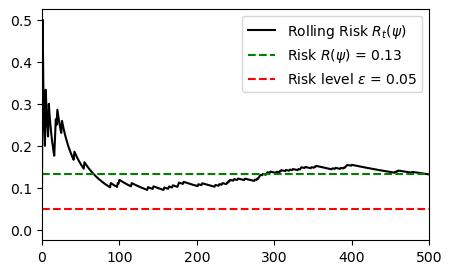

In [485]:
plt.figure(figsize=(5, 3))
plt.plot(stream_risk, label=r"Rolling Risk $R_{t}(\psi)$", color='black')
plt.axhline(stream_losses.mean(), color='green', linestyle='--', label=rf"Risk $R(\psi)$ = {stream_losses.mean():.2f}")
plt.axhline(eps, color='red', linestyle='--', label=rf"Risk level $\epsilon$ = {eps}")
plt.legend()

# plt.ylim(0.0, 0.2)
plt.xlim(0, 500)

In [529]:
print(f"Estimated error rate of FP + FN:", ((1 - ood_prob) * eps + ood_prob * (svhn_test_losses[thresh_id] < thresh).sum()/svhn_test_losses[thresh_id].shape[0]).item())

Estimated error rate of FP + FN: 0.14741703867912292


#### Evidence collection (constant bets of 1)

Build wealth process with betting scores $E_t = 1 + \lambda_t \cdot (\ell(X_t, Y_t) - \epsilon)$

Wealth process with product: $W_t = \prod_{s=1}^{t} E_s$

Wealth process with sum: $W_t = (1/t) \sum_{s=1}^{t} E_s$

In [487]:
def get_stopping_time(e_process, eps):
    t_ev_candidate = torch.where(e_process >= 1/eps)[0]
    if len(t_ev_candidate) == 0:
        t_ev = T
    else:
        t_ev = t_ev_candidate.min()
    return t_ev

In [530]:
stream_lam = torch.ones(T)

In [531]:
stream_eval = torch.ones(T) + stream_lam * (stream_losses - eps)
stream_eprod = torch.cumprod(stream_eval, dim=0)
stream_esum = torch.cumsum(stream_eval, dim=0) / torch.arange(1, T+1)

In [532]:
stream_eval[:50], stream_eprod[:50], stream_esum[:50]

(tensor([0.9500, 0.9500, 0.9500, 0.9500, 1.9500, 0.9500, 0.9500, 0.9500, 0.9500,
         0.9500, 0.9500, 0.9500, 0.9500, 0.9500, 0.9500, 0.9500, 0.9500, 0.9500,
         0.9500, 0.9500, 1.9500, 0.9500, 0.9500, 0.9500, 0.9500, 0.9500, 1.9500,
         0.9500, 0.9500, 0.9500, 0.9500, 0.9500, 0.9500, 0.9500, 0.9500, 0.9500,
         0.9500, 0.9500, 0.9500, 0.9500, 0.9500, 0.9500, 0.9500, 0.9500, 0.9500,
         0.9500, 1.9500, 0.9500, 0.9500, 0.9500]),
 tensor([0.9500, 0.9025, 0.8574, 0.8145, 1.5883, 1.5089, 1.4334, 1.3618, 1.2937,
         1.2290, 1.1675, 1.1092, 1.0537, 1.0010, 0.9510, 0.9034, 0.8582, 0.8153,
         0.7746, 0.7358, 1.4349, 1.3631, 1.2950, 1.2302, 1.1687, 1.1103, 2.1651,
         2.0568, 1.9540, 1.8563, 1.7635, 1.6753, 1.5915, 1.5119, 1.4363, 1.3645,
         1.2963, 1.2315, 1.1699, 1.1114, 1.0558, 1.0031, 0.9529, 0.9053, 0.8600,
         0.8170, 1.5931, 1.5135, 1.4378, 1.3659]),
 tensor([0.9500, 0.9500, 0.9500, 0.9500, 1.1500, 1.1167, 1.0929, 1.0750, 1.0611,
       

Stopping time E-prod: 104
Stopping time E-sum: 10000


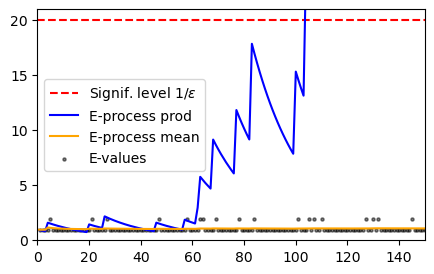

In [533]:
plt.figure(figsize=(5, 3))
plt.axhline(y=1/eps, color="red", linestyle="--", label=r"Signif. level $1/\epsilon$")
plt.plot(stream_eprod, label="E-process prod", color="blue")
plt.plot(stream_esum, label="E-process mean", color="orange")
plt.scatter(torch.arange(1, T+1), stream_eval, label="E-values", color="black", s=5, alpha=0.5)
plt.legend()

plt.ylim(-0.01, 1/eps + 1)
# plt.ylim(-0.01, 2)
plt.xlim(0, 150)

print(f"Stopping time E-prod: {get_stopping_time(stream_eprod, eps)}")
print(f"Stopping time E-sum: {get_stopping_time(stream_esum, eps)}")

With burn-in period

In [492]:
burn_in = 100

stream_lam = torch.cat([torch.zeros(burn_in), torch.ones(T - burn_in)])

In [493]:
stream_eval = torch.ones(T) + stream_lam * (stream_losses - eps)
stream_eprod = torch.cumprod(stream_eval, dim=0)
stream_esum = torch.cumsum(stream_eval, dim=0) / torch.arange(1, T+1)

In [494]:
stream_eval[75:125], stream_eprod[75:125], stream_esum[75:125]

(tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
         1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
         1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.9500, 0.9500,
         0.9500, 0.9500, 0.9500, 0.9500, 0.9500, 0.9500, 0.9500, 0.9500, 0.9500,
         0.9500, 0.9500, 0.9500, 0.9500, 0.9500, 1.9500, 0.9500, 0.9500, 0.9500,
         0.9500, 0.9500, 0.9500, 0.9500, 0.9500]),
 tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
         1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
         1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.9500, 1.8525,
         1.7599, 1.6719, 1.5883, 1.5089, 1.4334, 1.3618, 1.2937, 1.2290, 1.1675,
         1.1092, 1.0537, 1.0010, 0.9510, 0.9034, 1.7617, 1.6736, 1.5899, 1.5104,
         1.4349, 1.3631, 1.2950, 1.2302, 1.1687]),
 tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
       

Stopping time E-prod: 207
Stopping time E-sum: 10000


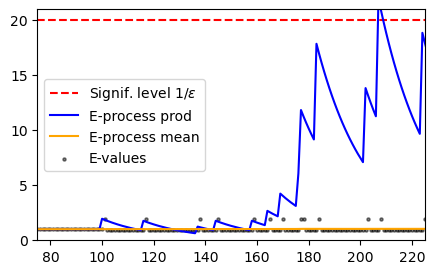

In [495]:

plt.figure(figsize=(5, 3))
plt.axhline(y=1/eps, color="red", linestyle="--", label=r"Signif. level $1/\epsilon$")
plt.plot(stream_eprod, label="E-process prod", color="blue")
plt.plot(stream_esum, label="E-process mean", color="orange")
plt.scatter(torch.arange(1, T+1), stream_eval, label="E-values", color="black", s=5, alpha=0.5)
plt.legend()

plt.ylim(-0.01, 1/eps + 1)
# plt.ylim(-0.01, 2)
plt.xlim(75, 225)

print(f"Stopping time E-prod: {get_stopping_time(stream_eprod, eps)}")
print(f"Stopping time E-sum: {get_stopping_time(stream_esum, eps)}")

#### Evidence collection (adaptive bets)

Adaptive bet rate at every step $t$: $\lambda_t = \arg \max_{\lambda \in (0, 1/\epsilon)} \sum_{s=1}^{t-1} \log(1 + \lambda \cdot (\ell(X_s, Y_s) - \epsilon))$

In [496]:
lams = thresh_grid(0, (1/eps)-0.1, 0.1)
lam_growth = torch.ones((len(lams), T-1))

for i, lam in enumerate(lams):
    growth = torch.log(torch.ones(T) + lam * (stream_losses - eps))
    lam_growth[i] = torch.cumsum(growth, dim=0)[0:-1] # growth until t-1 for t
    

In [497]:
lam_init = torch.ones(1)
lam_gr, lam_idx = lam_growth.max(dim=0)
lam_opt = torch.cat([lam_init, lams[lam_idx]])

(0.0, 500.0)

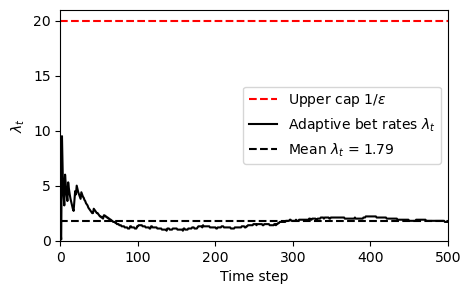

In [498]:
plt.figure(figsize=(5, 3))
plt.axhline(y=1/eps, color="red", linestyle="--", label=r"Upper cap $1/\epsilon$")
plt.plot(lam_opt, label=r"Adaptive bet rates $\lambda_t$", color="black")
plt.axhline(y=lam_opt.mean(), color="black", linestyle="--", label=rf"Mean $\lambda_t$ = {lam_opt.mean():.2f}")
plt.legend()

plt.xlabel("Time step")
plt.ylabel(r"$\lambda_t$")
plt.ylim(-0.01, 1/eps + 1)
# plt.ylim(-0.01, 2)
plt.xlim(0, 500)


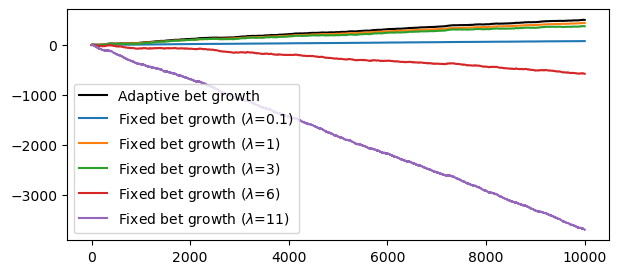

In [499]:
fixed_lam = [0.1, 1, 3, 6, 11]

plt.figure(figsize=(7, 3))
plt.plot(lam_gr, label=r"Adaptive bet growth", color="black")
for f_l in fixed_lam:
    plt.plot(lam_growth[torch.where(lams == f_l)[0]].squeeze(0), label=rf"Fixed bet growth ($\lambda$={f_l})")    
plt.legend()
# plt.xlim(0, 500)

In [500]:
stream_eval = torch.ones(T) + lam_opt * (stream_losses - eps)
stream_eprod = torch.cumprod(stream_eval, dim=0)
stream_esum = torch.cumsum(stream_eval, dim=0) / torch.arange(1, T+1)

In [501]:
stream_eval[:50], stream_eprod[:50], stream_esum[:50]

(tensor([0.9500, 1.0950, 0.5250, 0.7000, 0.7900, 4.0400, 0.7000, 0.7500, 0.7900,
         4.4200, 0.7350, 0.7650, 0.7900, 0.8100, 0.8250, 0.8400, 0.8550, 3.5650,
         4.4200, 0.7750, 4.9900, 0.7500, 0.7650, 0.7800, 0.7900, 0.8000, 4.6100,
         0.7800, 0.7900, 0.8000, 0.8050, 0.8150, 0.8200, 0.8300, 0.8350, 0.8400,
         0.8500, 0.8550, 0.8600, 0.8650, 0.8700, 0.8750, 3.3750, 0.8550, 0.8600,
         0.8650, 0.8700, 0.8750, 0.8750, 0.8800]),
 tensor([ 0.9500,  1.0403,  0.5461,  0.3823,  0.3020,  1.2201,  0.8541,  0.6406,
          0.5060,  2.2367,  1.6440,  1.2577,  0.9935,  0.8048,  0.6639,  0.5577,
          0.4768,  1.6999,  7.5137,  5.8231, 29.0574, 21.7930, 16.6717, 13.0039,
         10.2731,  8.2185, 37.8871, 29.5520, 23.3460, 18.6768, 15.0349, 12.2534,
         10.0478,  8.3397,  6.9636,  5.8494,  4.9720,  4.2511,  3.6559,  3.1624,
          2.7513,  2.4074,  8.1248,  6.9467,  5.9742,  5.1677,  4.4959,  3.9339,
          3.4422,  3.0291]),
 tensor([0.9500, 1.0225, 0.85

Stopping time E-prod: 20
Stopping time E-sum: 10000


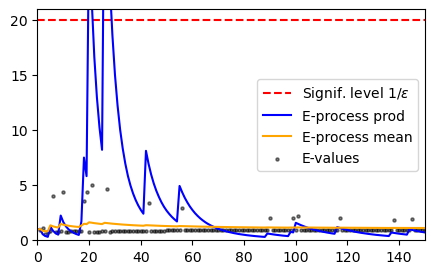

In [502]:

plt.figure(figsize=(5, 3))
plt.axhline(y=1/eps, color="red", linestyle="--", label=r"Signif. level $1/\epsilon$")
plt.plot(stream_eprod, label="E-process prod", color="blue")
plt.plot(stream_esum, label="E-process mean", color="orange")
plt.scatter(torch.arange(1, T+1), stream_eval, label="E-values", color="black", s=5, alpha=0.5)
plt.legend()

plt.ylim(-0.01, 1/eps + 1)
# plt.ylim(-0.01, 2)
plt.xlim(0, 150)

print(f"Stopping time E-prod: {get_stopping_time(stream_eprod, eps)}")
print(f"Stopping time E-sum: {get_stopping_time(stream_esum, eps)}")

With burn-in

In [503]:
burn_in = 100

stream_lam = torch.cat([torch.zeros(burn_in), lam_opt[burn_in:T]])

(0.0, 500.0)

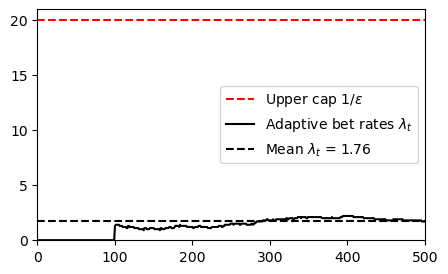

In [504]:
plt.figure(figsize=(5, 3))
plt.axhline(y=1/eps, color="red", linestyle="--", label=r"Upper cap $1/\epsilon$")
plt.plot(stream_lam, label=r"Adaptive bet rates $\lambda_t$", color="black")
plt.axhline(y=stream_lam.mean(), color="black", linestyle="--", label=rf"Mean $\lambda_t$ = {stream_lam.mean():.2f}")
plt.legend()

plt.ylim(-0.01, 1/eps + 1)
# plt.ylim(-0.01, 2)
plt.xlim(0, 500)

In [505]:
stream_eval = torch.ones(T) + stream_lam * (stream_losses - eps)
stream_eprod = torch.cumprod(stream_eval, dim=0)
stream_esum = torch.cumsum(stream_eval, dim=0) / torch.arange(1, T+1)

In [506]:
stream_eval[75:125], stream_eprod[75:125], stream_esum[75:125]

(tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
         1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
         1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 2.2350, 0.9300,
         0.9300, 0.9300, 0.9300, 0.9300, 0.9350, 0.9350, 0.9350, 0.9350, 0.9400,
         0.9400, 0.9400, 0.9400, 0.9400, 0.9450, 2.0450, 0.9350, 0.9350, 0.9400,
         0.9400, 0.9400, 0.9400, 0.9400, 0.9400]),
 tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
         1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
         1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 2.2350, 2.0786,
         1.9331, 1.7977, 1.6719, 1.5549, 1.4538, 1.3593, 1.2709, 1.1883, 1.1170,
         1.0500, 0.9870, 0.9278, 0.8721, 0.8242, 1.6854, 1.5758, 1.4734, 1.3850,
         1.3019, 1.2238, 1.1504, 1.0813, 1.0165]),
 tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
       

Stopping time E-prod: 229
Stopping time E-sum: 10000


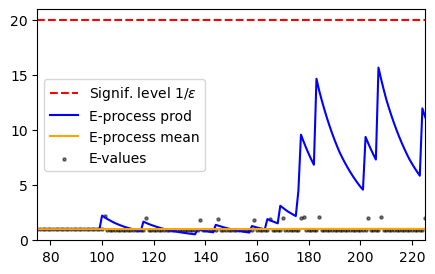

In [507]:
plt.figure(figsize=(5, 3))
plt.axhline(y=1/eps, color="red", linestyle="--", label=r"Signif. level $1/\epsilon$")
plt.plot(stream_eprod, label="E-process prod", color="blue")
plt.plot(stream_esum, label="E-process mean", color="orange")
plt.scatter(torch.arange(1, T+1), stream_eval, label="E-values", color="black", s=5, alpha=0.5)
plt.legend()

plt.ylim(-0.01, 1/eps + 1)
# plt.ylim(-0.01, 2)
plt.xlim(75, 225)

print(f"Stopping time E-prod: {get_stopping_time(stream_eprod, eps)}")
print(f"Stopping time E-sum: {get_stopping_time(stream_esum, eps)}")

#### Updating mechanism

Once the stopping threshold is met, an update to the initial risk-controlling threshold $\psi$ is triggered. One trivial update for the fixed OOD proportion setting could be to update calibration set with labelled examples and recompute $\psi$.

In [534]:
# stop_time = get_stopping_time(stream_eprod, eps).item()
stop_time = 1000

test_ood_mask = (stream_bern[:stop_time] == 1)
test_ood_idx = stream_idx[:stop_time][test_ood_mask].int()
test_id_idx = stream_idx[:stop_time][~test_ood_mask].int()

print(f"Stopping time: {stop_time} | OOD samples: {test_ood_mask.sum()} | ID samples: {test_ood_mask.shape[0] - test_ood_mask.sum()}")

Stopping time: 1000 | OOD samples: 157 | ID samples: 843


In [535]:
print("Incorporating test samples (both ID and OOD) into calibration set.")

losses = get_losses(thresh_cand, torch.cat([
    torch.Tensor(cifar10_conf[cal_idx]), torch.Tensor(cifar10_conf[test_id_idx]), torch.Tensor(svhn_conf[test_ood_idx])
    ])
                    )
losses[:, -len(test_ood_idx):] = 1.0 - losses[:, -len(test_ood_idx):] # FN: outlier as inlier
risk = losses.mean(dim=1)

thresh_id, thresh_ids, pval = get_ltt_thresh(losses, eps, delta, binary_loss=True)

print(f"Selected threshold: {thresh_cand[thresh_id]}, p-value: {pval[thresh_id]}, risk: {risk[thresh_id]}")


Incorporating test samples (both ID and OOD) into calibration set.
Selected threshold: 0.5699999928474426, p-value: 0.08827460557222366, risk: 0.045249998569488525


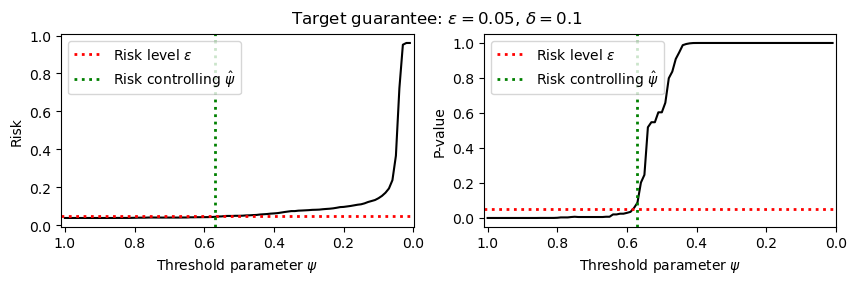

In [536]:
plot_thresh_risk_pval(thresh_cand, risk, pval, thresh_cand[thresh_id], eps, delta)

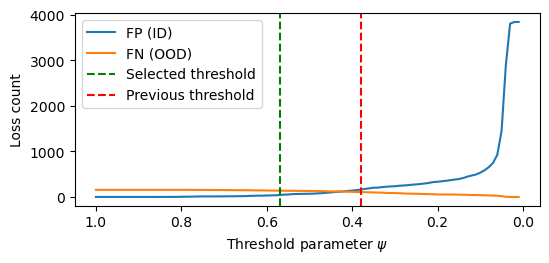

In [558]:
plt.figure(figsize=(6, 2.5))
plt.plot(thresh_cand, losses[:, :-len(test_ood_idx)].sum(dim=1), label="FP (ID)")
plt.plot(thresh_cand, losses[:, -len(test_ood_idx):].sum(dim=1), label="FN (OOD)")
plt.axvline(thresh_cand[thresh_id], color="green", linestyle="--", label="Selected threshold")
plt.axvline(thresh, color="red", linestyle="--", label="Previous threshold")
plt.xlabel(r"Threshold parameter $\psi$")
plt.gca().invert_xaxis()
plt.ylabel("Loss count")
plt.legend()

The higher number of FN for larger thresholds adds to a heavier tail mass of the risk, pushing the threshold up. In turn, the FP are controlled even stronger to counteract this effect. Overall, this will aim at controlling the total error rate.

TODO

In [538]:
# Check the selected threshold on the test set
test_losses = get_losses(thresh_cand, torch.tensor(cifar10_conf[~cal_idx]))
test_risk = test_losses.mean(dim=1)

print(f"Test risk: {test_risk[thresh_id]}")

Test risk: 0.01066666655242443


In [543]:
stream_bern = torch.zeros(T)
stream_idx = torch.zeros(T)
stream_losses = torch.zeros(T)

# generate data stream
for t in tqdm(range(0, T), desc="Time step"):
    
    # simulate test sample (in or out of distribution)
    bern = np.random.binomial(1, ood_prob)
    
    if bern == 0: # in distribution
        i = np.random.randint(0, cifar10_test_losses.shape[1])
        loss = cifar10_test_losses[thresh_id, i] # FP: inlier as outlier
    else: # out of distribution
        i = np.random.randint(0, svhn_test_losses.shape[1])
        loss = 1.0 - svhn_test_losses[thresh_id, i] # FN: outlier as inlier
    
    stream_bern[t] = bern
    stream_idx[t] = i
    stream_losses[t] = loss

Time step: 100%|██████████| 10000/10000 [00:00<00:00, 22479.59it/s]


In [544]:
stream_risk = torch.cumsum(stream_losses, dim=0) / torch.arange(1, T + 1)

(0.0, 500.0)

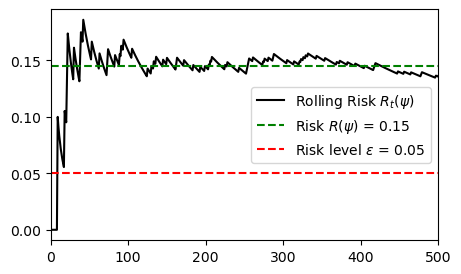

In [545]:
plt.figure(figsize=(5, 3))
plt.plot(stream_risk, label=r"Rolling Risk $R_{t}(\psi)$", color='black')
plt.axhline(stream_losses.mean(), color='green', linestyle='--', label=rf"Risk $R(\psi)$ = {stream_losses.mean():.2f}")
plt.axhline(eps, color='red', linestyle='--', label=rf"Risk level $\epsilon$ = {eps}")
plt.legend()

# plt.ylim(0.0, 0.2)
plt.xlim(0, 500)

In [546]:
print(f"Estimated error rate of FP + FN:", ((1 - ood_prob) * eps + ood_prob * (svhn_test_losses[thresh_id] < thresh).sum()/svhn_test_losses[thresh_id].shape[0]).item())

Estimated error rate of FP + FN: 0.17674055695533752


In [547]:
stream_lam = torch.ones(T)

In [548]:
stream_eval = torch.ones(T) + stream_lam * (stream_losses - eps)
stream_eprod = torch.cumprod(stream_eval, dim=0)
stream_esum = torch.cumsum(stream_eval, dim=0) / torch.arange(1, T+1)

In [549]:
stream_eval[:50], stream_eprod[:50], stream_esum[:50]

(tensor([0.9500, 0.9500, 0.9500, 0.9500, 0.9500, 0.9500, 0.9500, 0.9500, 0.9500,
         1.9500, 0.9500, 0.9500, 0.9500, 0.9500, 0.9500, 0.9500, 0.9500, 0.9500,
         1.9500, 0.9500, 0.9500, 1.9500, 1.9500, 0.9500, 0.9500, 0.9500, 0.9500,
         0.9500, 0.9500, 0.9500, 1.9500, 0.9500, 0.9500, 0.9500, 0.9500, 0.9500,
         0.9500, 0.9500, 1.9500, 1.9500, 0.9500, 0.9500, 1.9500, 0.9500, 0.9500,
         0.9500, 0.9500, 0.9500, 0.9500, 0.9500]),
 tensor([ 0.9500,  0.9025,  0.8574,  0.8145,  0.7738,  0.7351,  0.6983,  0.6634,
          0.6302,  1.2290,  1.1675,  1.1092,  1.0537,  1.0010,  0.9510,  0.9034,
          0.8582,  0.8153,  1.5899,  1.5104,  1.4349,  2.7980,  5.4562,  5.1833,
          4.9242,  4.6780,  4.4441,  4.2219,  4.0108,  3.8102,  7.4300,  7.0585,
          6.7055,  6.3703,  6.0518,  5.7492,  5.4617,  5.1886, 10.1178, 19.7297,
         18.7432, 17.8061, 34.7219, 32.9858, 31.3365, 29.7697, 28.2812, 26.8671,
         25.5238, 24.2476]),
 tensor([0.9500, 0.9500, 0.95

Stopping time E-prod: 42
Stopping time E-sum: 10000


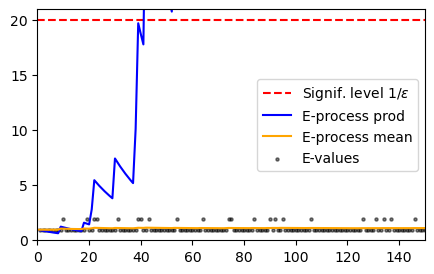

In [550]:
plt.figure(figsize=(5, 3))
plt.axhline(y=1/eps, color="red", linestyle="--", label=r"Signif. level $1/\epsilon$")
plt.plot(stream_eprod, label="E-process prod", color="blue")
plt.plot(stream_esum, label="E-process mean", color="orange")
plt.scatter(torch.arange(1, T+1), stream_eval, label="E-values", color="black", s=5, alpha=0.5)
plt.legend()

plt.ylim(-0.01, 1/eps + 1)
# plt.ylim(-0.01, 2)
plt.xlim(0, 150)

print(f"Stopping time E-prod: {get_stopping_time(stream_eprod, eps)}")
print(f"Stopping time E-sum: {get_stopping_time(stream_esum, eps)}")

#### Risk with growth profile

The previous setting's risk definition seems suboptimal because it converges to a fixed error proportion over time since it is a fraction with both changing numerator and denominator. Since the fraction is above the risk level, the goal of the e-process becomes simply to reject the null as fast as possible, and can be interpreted as a signal on non-representativity of the calibration data. With enough calibration set updates, the data should become representative enough of the fixed outlier proportion to tune the threshold appropriately. Also, the total error rate has competing interests in terms of FP and FN which want to push the threshold either way?

Instead it seems more sensible to have a risk definition with a growing profile, such that the risk starts at zero and grows over time. This could be achieved by either (1) using a risk that is formulated in terms of some counter (but has to be in [0,1]?) or using a fraction with a fixed denominator, or (2) introducing a shifting outlier proportion over time such that the numerator grows consistently. Then we should also see that the averaging-style e-process does something meaningful.